# Import Modules

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Read CSV

In [2]:
pd.set_option("display.max_columns", 30)

In [3]:
df = pd.read_csv("../csv_files/app_user_behavior_cleaned.csv")

df.shape

(50000, 25)

In [4]:
df.head()

,user_id,age,gender,country,device_type,app_version,sessions_per_week,avg_session_duration_min,daily_active_minutes,feature_clicks_per_session,notifications_opened_per_week,in_app_search_count,pages_viewed_per_session,crash_events_last_30_days,support_tickets_raised,days_since_last_login,subscription_type,ads_clicked_last_30_days,content_downloads,social_shares,rating_given,churn_risk_score,engagement_score,account_age_days,marketing_source
0,100000,56,Female,India,iOS,2.1,5,3.41,52.71,13,5,8,8,1,0,20,Basic,9,5,2,4.0,0.31,55.79,1152,Referral
1,100001,46,Male,UK,iOS,1.0,8,24.44,42.03,7,7,3,7,0,0,7,Free,8,3,3,3.0,0.87,82.39,1059,Email Campaign
2,100002,32,Female,UK,iOS,1.2,12,5.34,76.69,7,5,2,21,1,0,33,Free,11,6,1,2.0,0.63,42.49,678,Google Ads
3,100003,25,Male,India,Android,2.0,5,3.98,65.38,16,8,4,13,0,0,17,Basic,6,3,1,3.0,0.43,62.81,92,Organic
4,100004,38,Male,Australia,Android,1.0,10,12.85,57.06,13,7,3,15,0,0,21,Basic,4,4,2,5.0,0.43,38.21,772,Email Campaign


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   user_id                        50000 non-null  int64  
 1   age                            50000 non-null  int64  
 2   gender                         50000 non-null  str    
 3   country                        50000 non-null  str    
 4   device_type                    50000 non-null  str    
 5   app_version                    50000 non-null  float64
 6   sessions_per_week              50000 non-null  int64  
 7   avg_session_duration_min       50000 non-null  float64
 8   daily_active_minutes           50000 non-null  float64
 9   feature_clicks_per_session     50000 non-null  int64  
 10  notifications_opened_per_week  50000 non-null  int64  
 11  in_app_search_count            50000 non-null  int64  
 12  pages_viewed_per_session       50000 non-null  int64  
 1

In [6]:
numeric_features = []
categorical_features = []

for column in df.columns:
    if df[column].dtype == "str":
        categorical_features.append(column)
    else:
        numeric_features.append(column)

# Exploratory Data Analysis

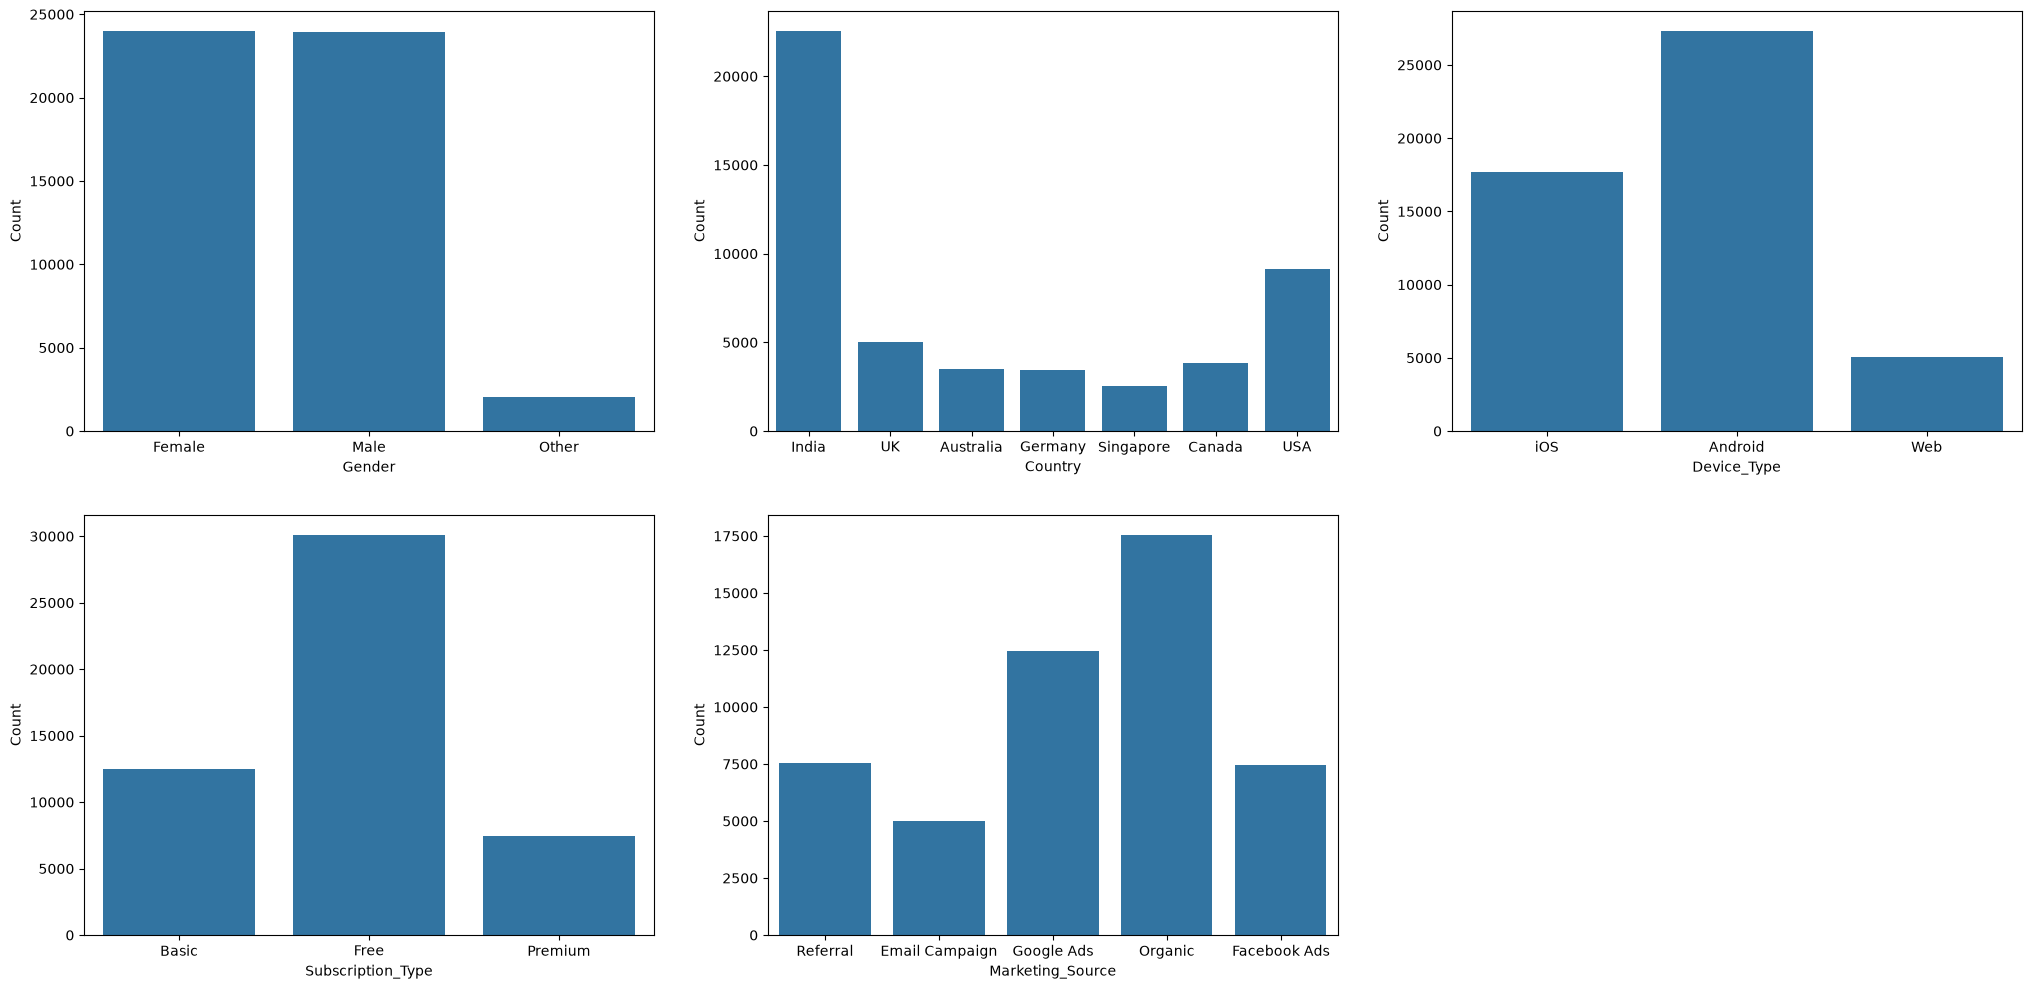

In [7]:
plt.figure(figsize=(25, 12))

for i, column in enumerate(categorical_features, 1):
    plt.subplot(2, 3, i)
    sns.countplot(x=df[column])
    plt.xlabel(column.title())
    plt.ylabel("Count")

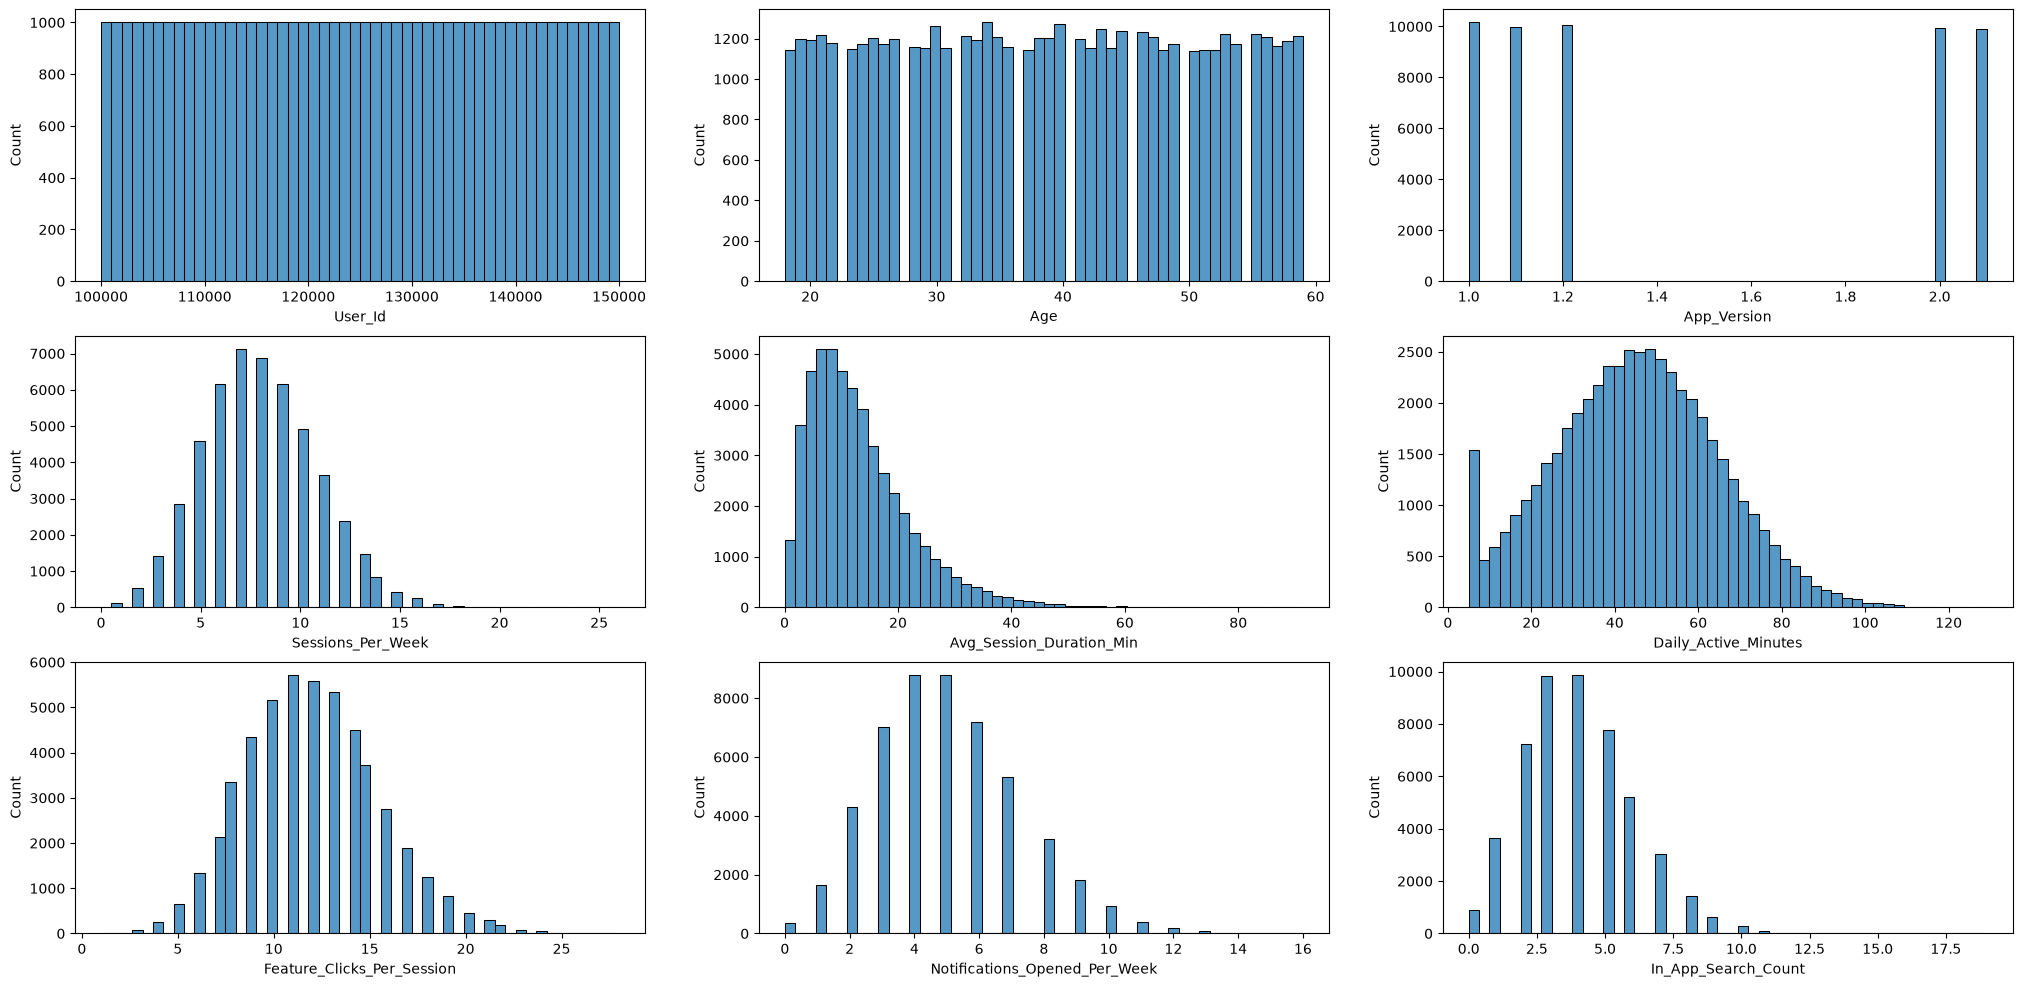

In [8]:
plt.figure(figsize=(25, 12))

for i, column in enumerate(numeric_features[:9], 1):
    plt.subplot(3, 3, i)
    sns.histplot(x=df[column], bins=50)
    plt.xlabel(column.title())
    plt.ylabel("Count")

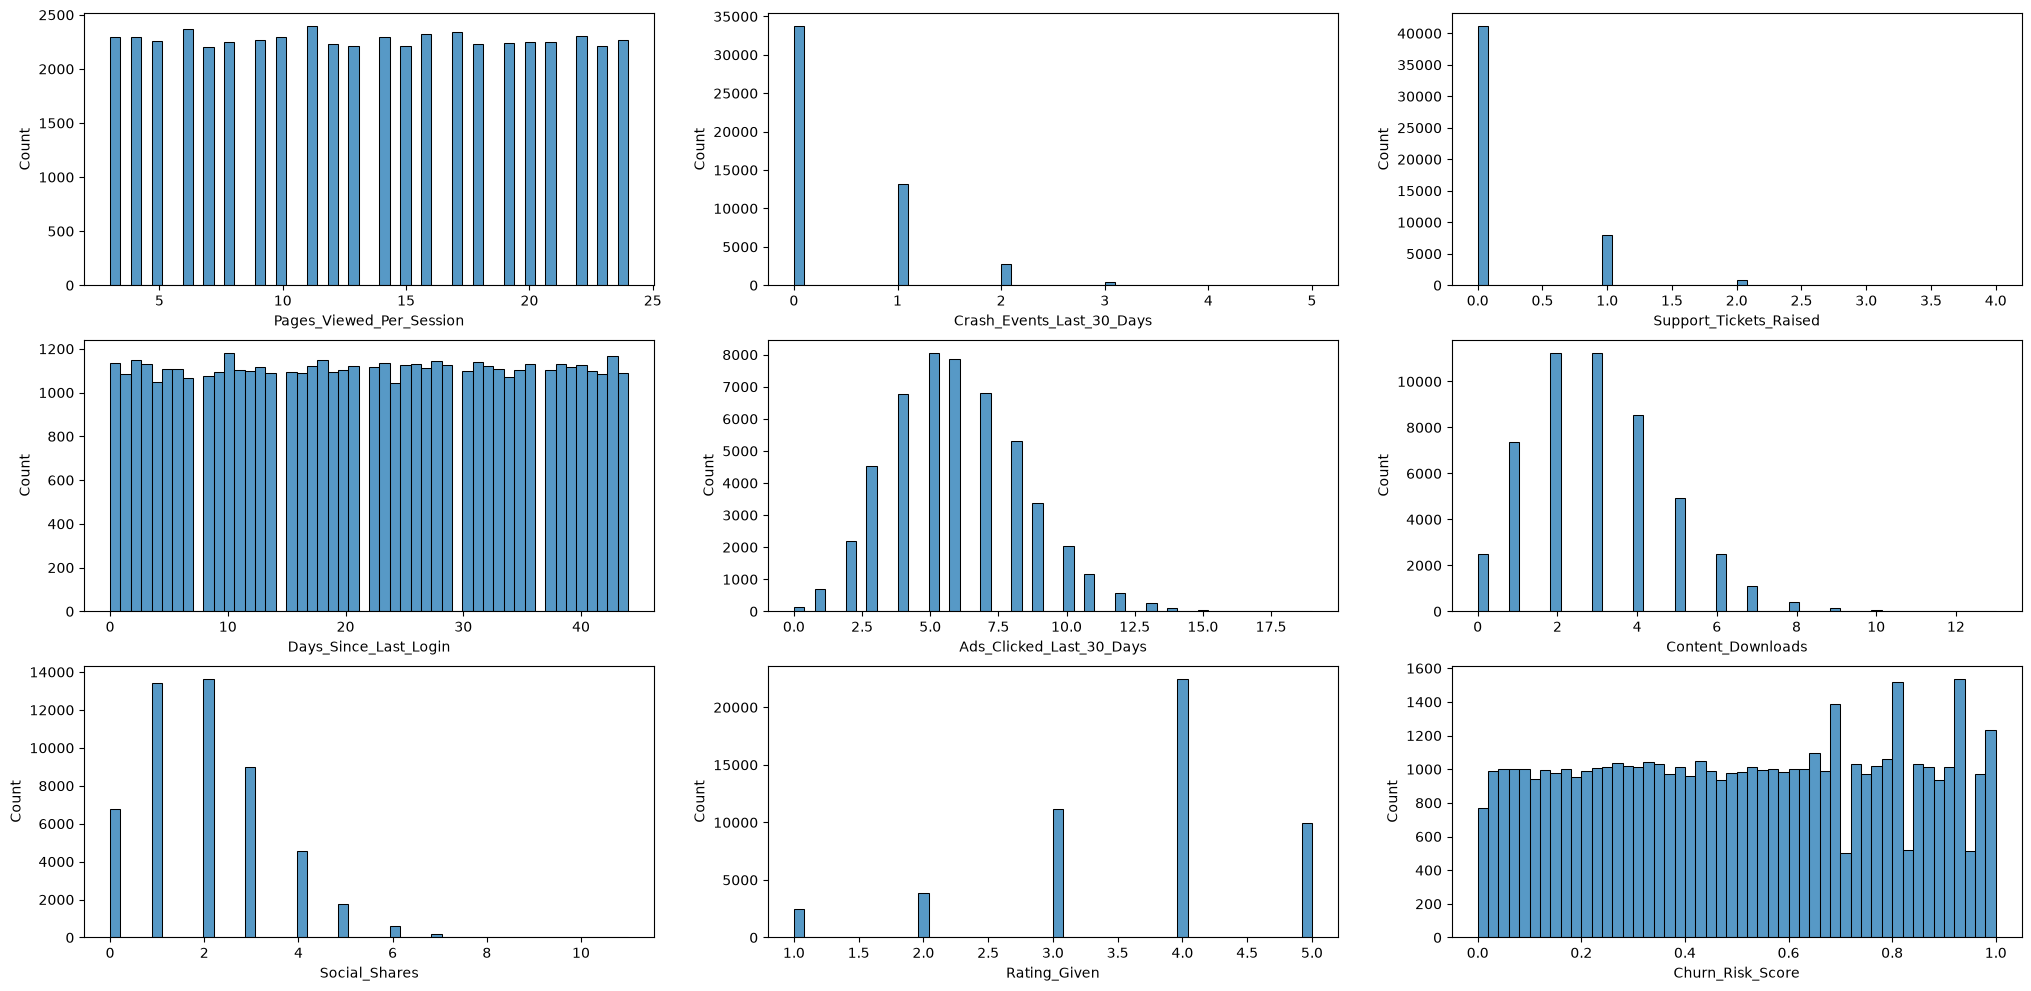

In [9]:
plt.figure(figsize=(25, 12))

for i, column in enumerate(numeric_features[9:18], 1):
    plt.subplot(3, 3, i)
    sns.histplot(x=df[column], bins=50)
    plt.xlabel(column.title())
    plt.ylabel("Count")

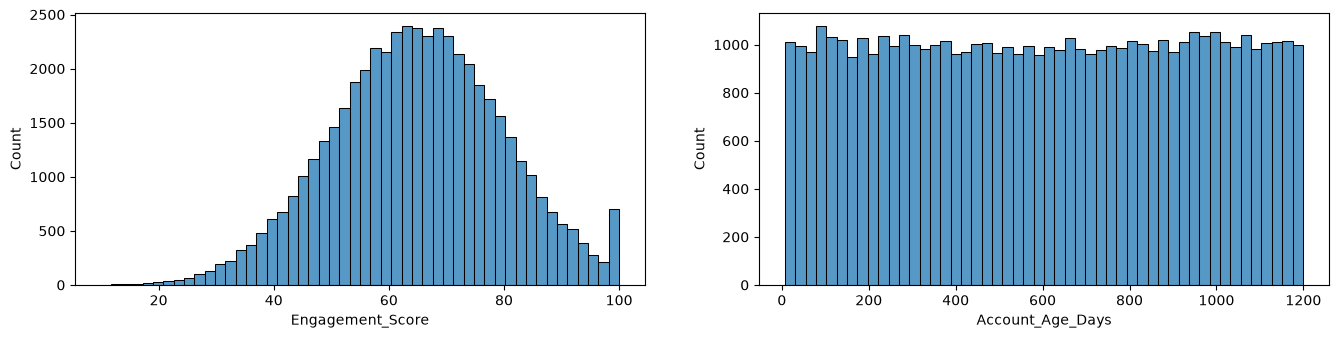

In [10]:
plt.figure(figsize=(25, 12))

for i, column in enumerate(numeric_features[18:], 1):
    plt.subplot(3, 3, i)
    sns.histplot(x=df[column], bins=50)
    plt.xlabel(column.title())
    plt.ylabel("Count")

---

In [11]:
df_copy = df.copy()

---

## Categorical Encoding

In [12]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

### Ordinal Encode

In [13]:
df["subscription_type"].value_counts()

subscription_type
Free       30088
Basic      12495
Premium     7417
Name: count, dtype: int64

In [14]:
ordinal_encoder = OrdinalEncoder(
    categories=[["Free", "Basic", "Premium"]]
)

df["subscription_type"] = ordinal_encoder.fit_transform(df[["subscription_type"]])

df["subscription_type"] = df["subscription_type"].astype(int)

In [15]:
df["subscription_type"].value_counts()

subscription_type
0    30088
1    12495
2     7417
Name: count, dtype: int64

---

# Model Implement

In [16]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN

from sklearn.decomposition import PCA

from sklearn.metrics import silhouette_score

## Feature Selection & Standardization

In [84]:
scaler = StandardScaler()

features = ["avg_session_duration_min", "pages_viewed_per_session"]

x_scaled = df[features].copy()

x_scaled[features] = scaler.fit_transform(df[features])


## WCSS Plot

In [85]:
wcss = []

for k in range(2,11):
    
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(x_scaled)

    wcss.append(model.inertia_)

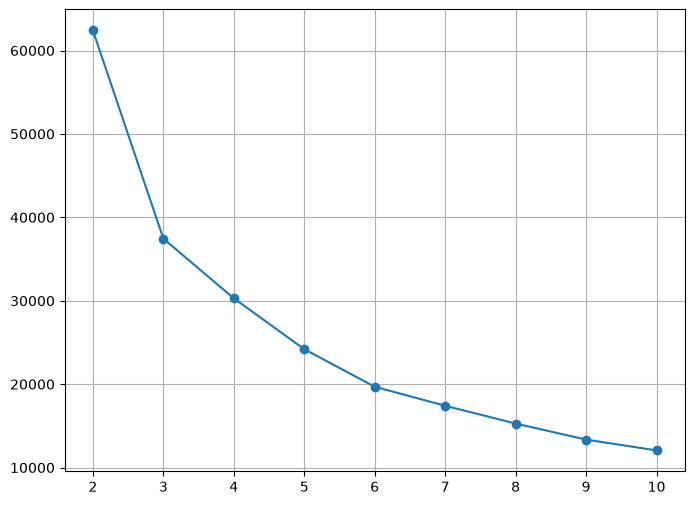

In [86]:
plt.figure(figsize=(8,6))

plt.plot(range(2,11), wcss, marker="o")

plt.grid(True)

## Model Training

In [87]:
model = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

model.fit(x_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",42
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](4, 2)","[[-0.

In [88]:
df["cluster"] = model.labels_

labels = model.labels_

In [89]:
score = silhouette_score(x_scaled, labels)

print(f"Silhouette Score: {score:.4f}")

Silhouette Score: 0.3925


## Scatter Plot

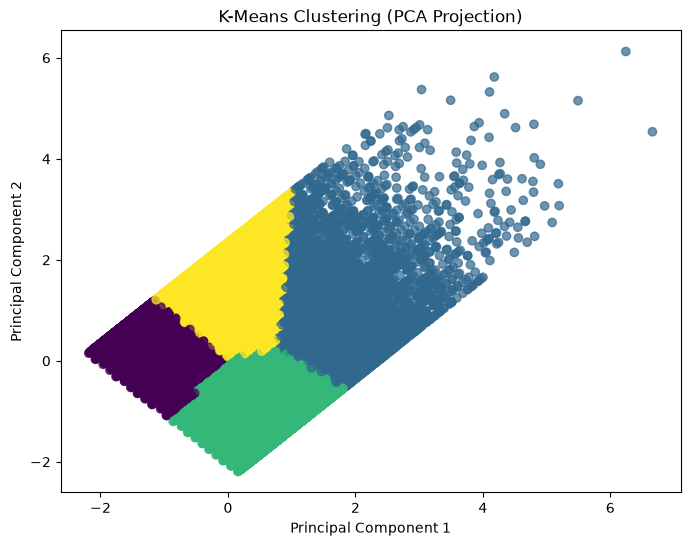

In [90]:
pca = PCA(n_components=2)

x_pca = pca.fit_transform(x_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    x_pca[:,0],
    x_pca[:,1],
    c=model.labels_,
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clustering (PCA Projection)")

plt.show()

In [91]:
pca.explained_variance_ratio_

array([0.50255845, 0.49744155])

- I experimented with multiple feature combination and evaluated them using `Silhoutte Score`.

- The combination of `avg_session_duration_min` and `pages_viewed_per_session` consitently produced the highest score.

- Adding additional features reduced cluster quality and the introduced noise rather than improving perfomance.

- Therefore, the final `K-Means` model was build using these two features.

---

## Assigning Cluster Labels

In [92]:
df.groupby('cluster')[["avg_session_duration_min", "pages_viewed_per_session"]].mean()

,avg_session_duration_min,pages_viewed_per_session
cluster,,
0,7.377604,8.182891
1,30.270007,17.048358
2,9.883624,19.271603
3,19.704995,8.152038


In [93]:
mapping = {
    1:0,
    3:1,
    2:2,
    0:3
}

df["cluster"] = df["cluster"].map(mapping)

In [94]:
df.groupby('cluster')[["avg_session_duration_min", "pages_viewed_per_session"]].mean().round(2)

,avg_session_duration_min,pages_viewed_per_session
cluster,,
0,30.27,17.05
1,19.70,8.15
2,9.88,19.27
3,7.38,8.18


In [95]:
cluster_labels = {
    0: "High Active User",
    1: "Moderate Active User",
    2: "Low Active User",
    3: "Occasional User"
}

df["labels"] = df["cluster"].map(cluster_labels)

In [96]:
df.head()

,user_id,age,gender,country,device_type,app_version,sessions_per_week,avg_session_duration_min,daily_active_minutes,feature_clicks_per_session,notifications_opened_per_week,in_app_search_count,pages_viewed_per_session,crash_events_last_30_days,support_tickets_raised,days_since_last_login,subscription_type,ads_clicked_last_30_days,content_downloads,social_shares,rating_given,churn_risk_score,engagement_score,account_age_days,marketing_source,cluster,labels
0,100000,56,Female,India,iOS,2.1,5,3.41,52.71,13,5,8,8,1,0,20,1,9,5,2,4.0,0.31,55.79,1152,Referral,3,Occasional User
1,100001,46,Male,UK,iOS,1.0,8,24.44,42.03,7,7,3,7,0,0,7,0,8,3,3,3.0,0.87,82.39,1059,Email Campaign,1,Moderate Active User
2,100002,32,Female,UK,iOS,1.2,12,5.34,76.69,7,5,2,21,1,0,33,0,11,6,1,2.0,0.63,42.49,678,Google Ads,2,Low Active User
3,100003,25,Male,India,Android,2.0,5,3.98,65.38,16,8,4,13,0,0,17,1,6,3,1,3.0,0.43,62.81,92,Organic,3,Occasional User
4,100004,38,Male,Australia,Android,1.0,10,12.85,57.06,13,7,3,15,0,0,21,1,4,4,2,5.0,0.43,38.21,772,Email Campaign,2,Low Active User


---